# Evaluación de Algoritmos de Particionamiento Territorial (Europa 1836)

Este Notebook presenta las salidas cartográficas de los algoritmos de optimización desarrollados para el particionamiento del grafo plano dual de Europa, basado en el conjunto de datos demográficos del *Historical Flavour Mod*.

In [9]:
from src.graph.graph import LoadGeographicGraph, LoadPartitionedGraph
from src.builders.vertex_builder import ImportVertices, CallEuropeanProvinces
from src.graph.show import ShowGeographicGraph, ShowCulturalMap, ShowPartitionedGraph, ShowSatisfactionMap
from src.graph.partition import Partition

base_graph = LoadGeographicGraph()
vertices = ImportVertices()
european_provinces = CallEuropeanProvinces()

print(f"Grafo base cargado exitosamente. Vértices: {len(base_graph.nodes)}, Aristas: {len(base_graph.edges)}")

Grafo base cargado exitosamente. Vértices: 835, Aristas: 2055


## 1. Análisis del Entorno Geográfico y Demográfico Base

Antes de evaluar las particiones políticas, visualizamos la estructura de la red (Grafo Base) y la distribución de los bloques culturales sin restricciones de fronteras.

Cargando resultados: Vista Geográfica y Cultural...


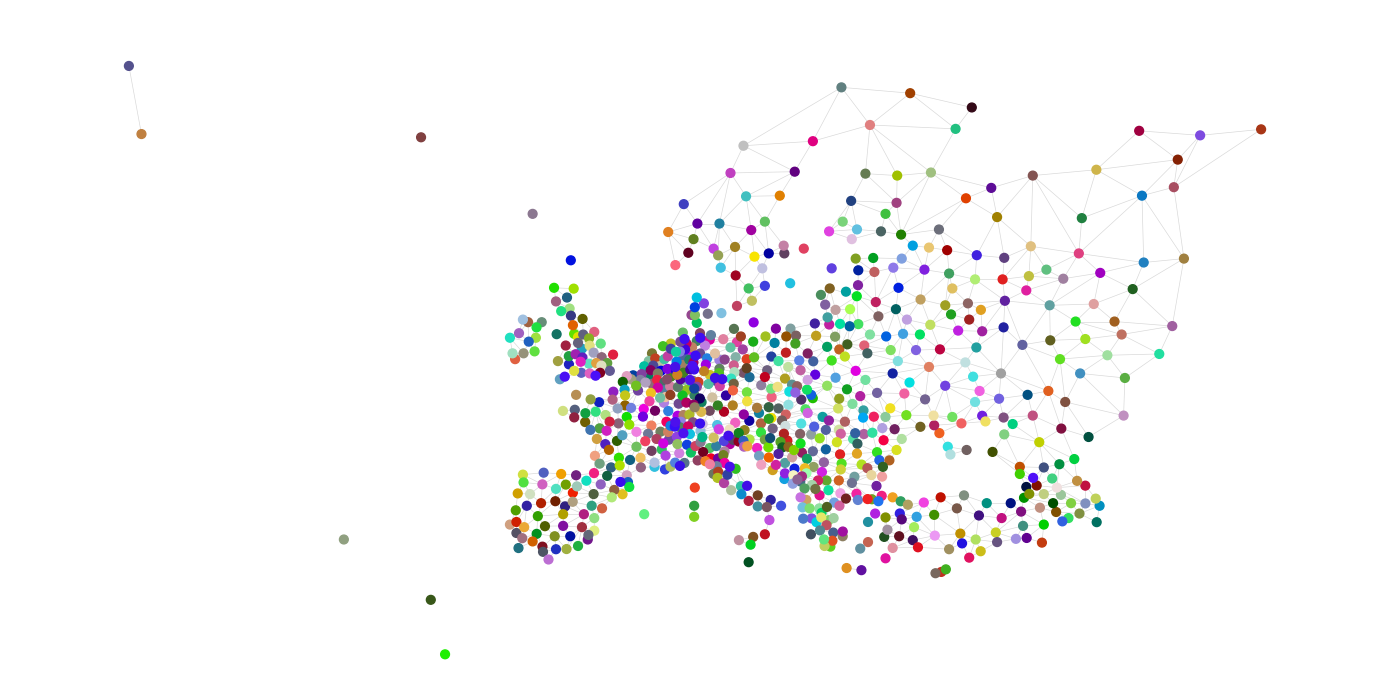

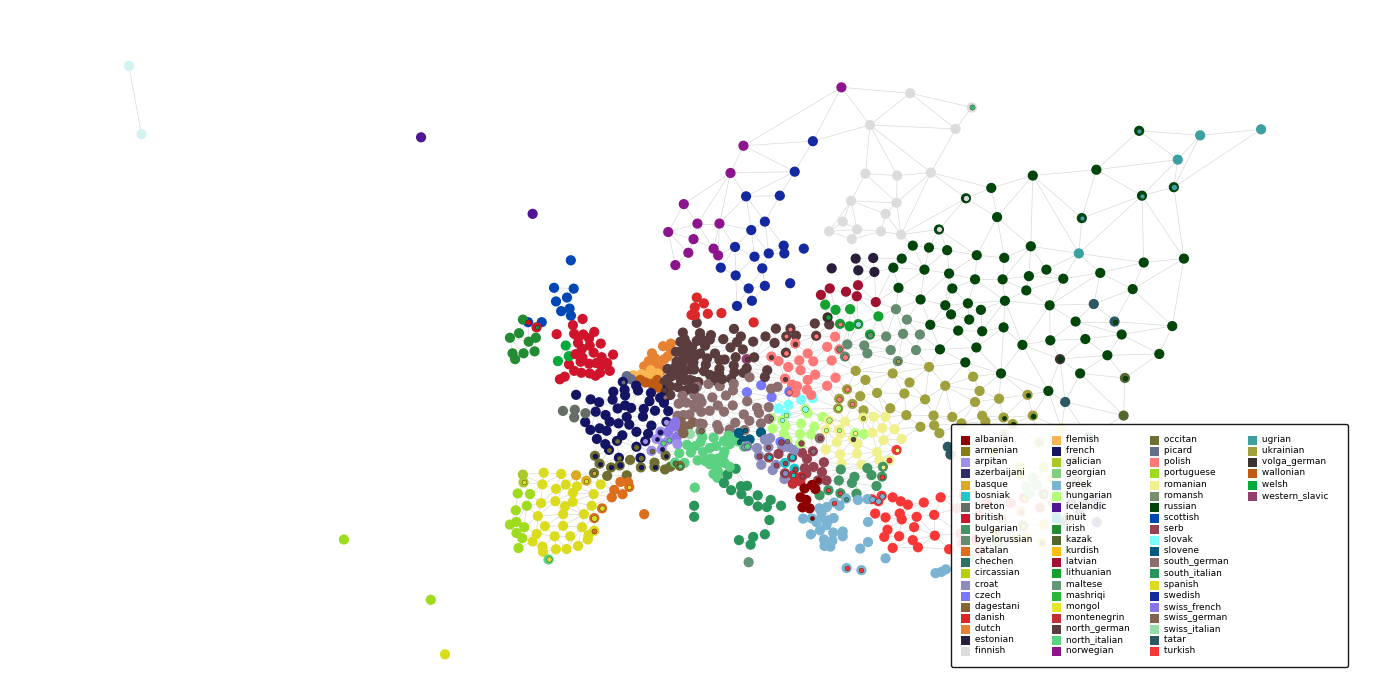

In [10]:
# 1. VISTAS BASE
print("Cargando resultados: Vista Geográfica y Cultural...")

ShowGeographicGraph(base_graph)
ShowCulturalMap(base_graph, include_metrics = False, show_labels = True)

## 2. Evaluación de la Partición Histórica Real (1836)

Cargamos y evaluamos el estado inicial de las fronteras geopolíticas reales de 1836 para establecer nuestra métrica base de comparación ($\Lambda(G) = 64.84\%$).

Cargando resultados: Partición Histórica 1836...


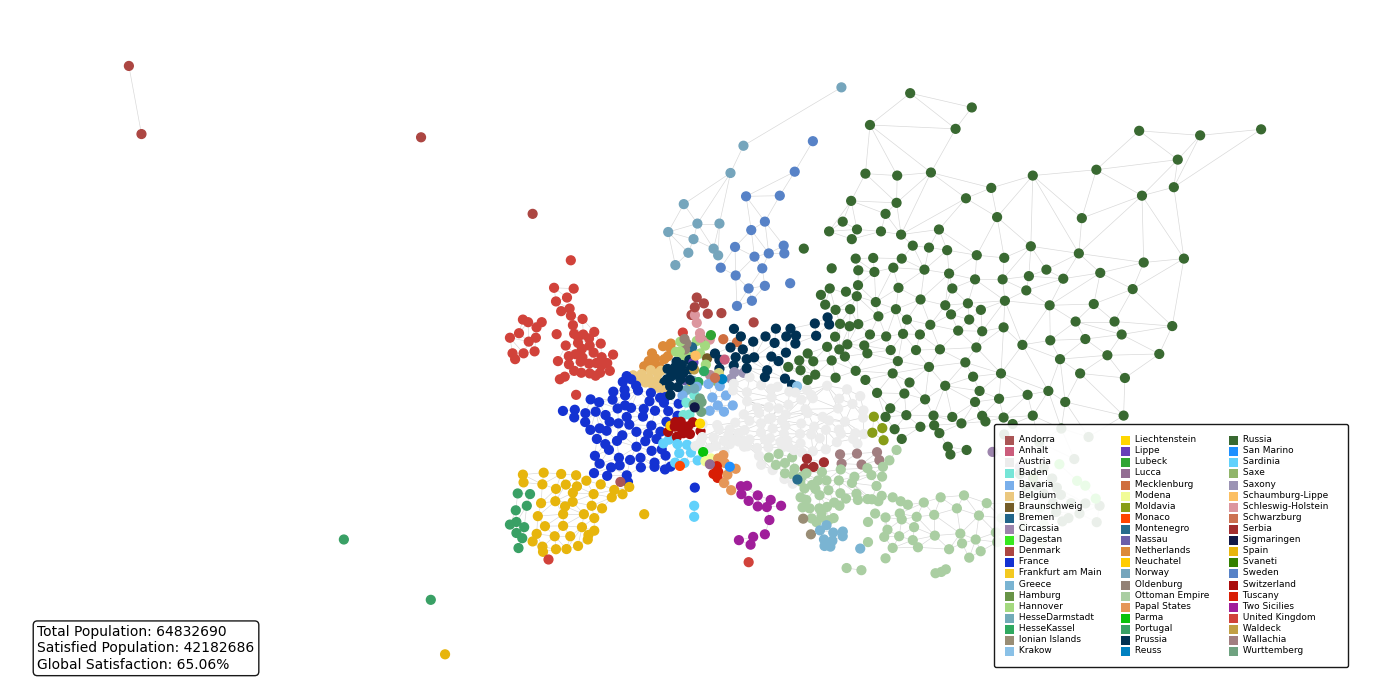

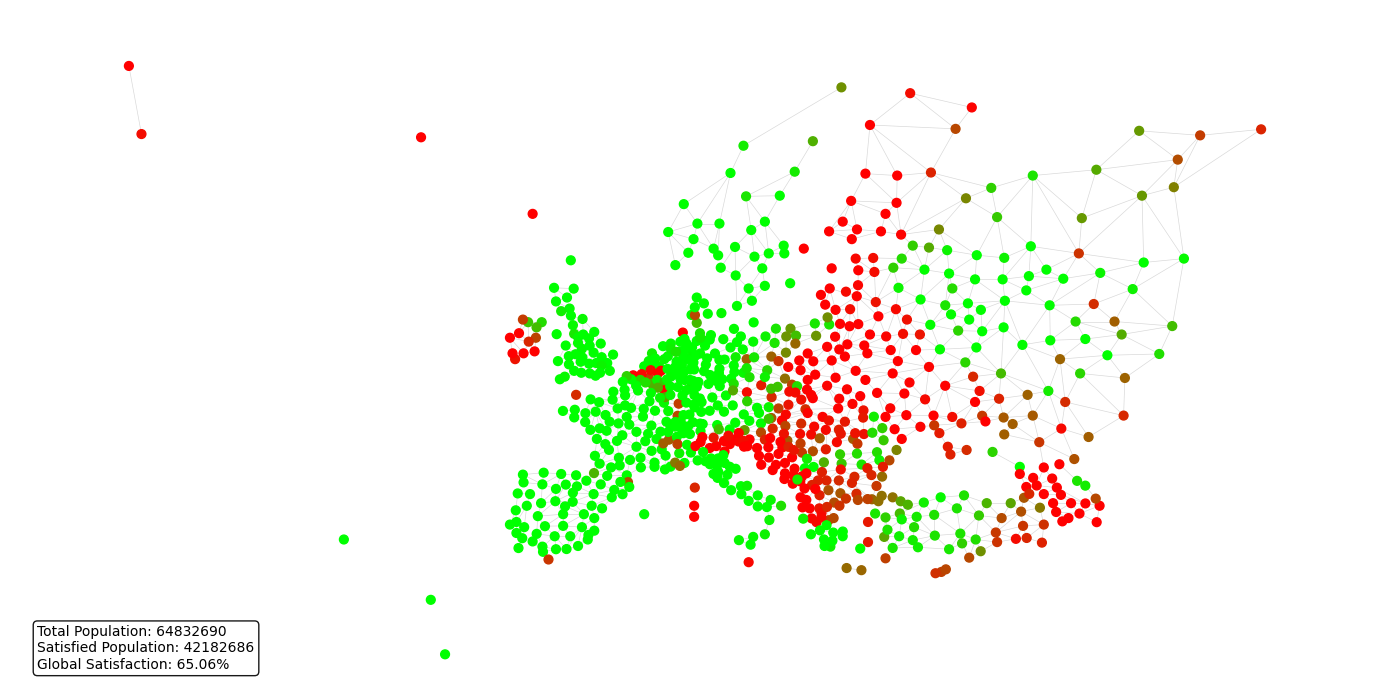

In [11]:
# 2. PARTICIÓN HISTÓRICA 1836
print("Cargando resultados: Partición Histórica 1836...")

# Cargar la partición imputada
partition_1836 = Partition.create_from_csv("1836imputated.csv")
partitioned_graph_1836 = LoadPartitionedGraph(base_graph, partition_1836)

# Renderizar salidas en el Notebook
ShowPartitionedGraph(partitioned_graph_1836, show_labels = True)
ShowSatisfactionMap(partitioned_graph_1836)

## 3. Evaluación de Algoritmos de Particionamiento Territoriales

A continuación, se importan y evalúan las soluciones óptimas generadas por cada uno de los motores de particionamiento. Cada configuración se carga desde su respectivo archivo histórico CSV y se acopla dinámicamente al grafo geográfico base para extraer sus métricas y renderizar el mapa político y el mapa de calor satisfacción cultural.

Cargando resultados: Algoritmo Multistart...


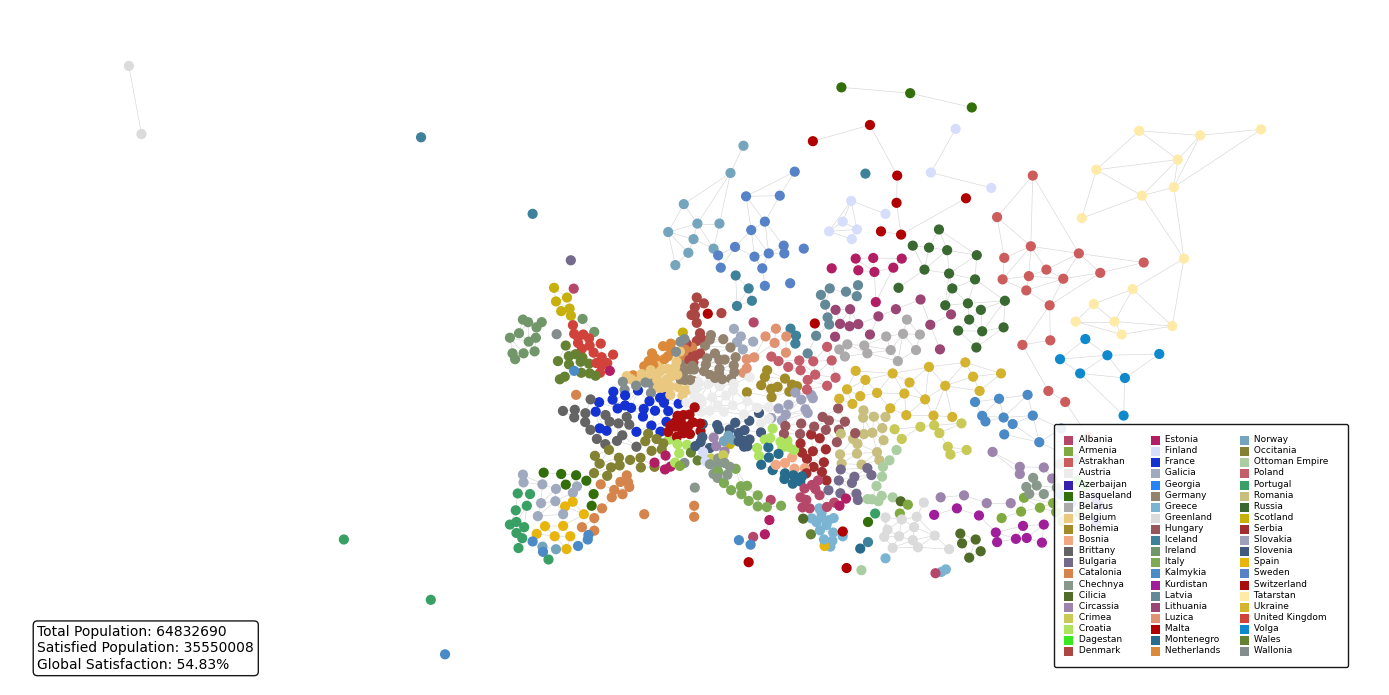

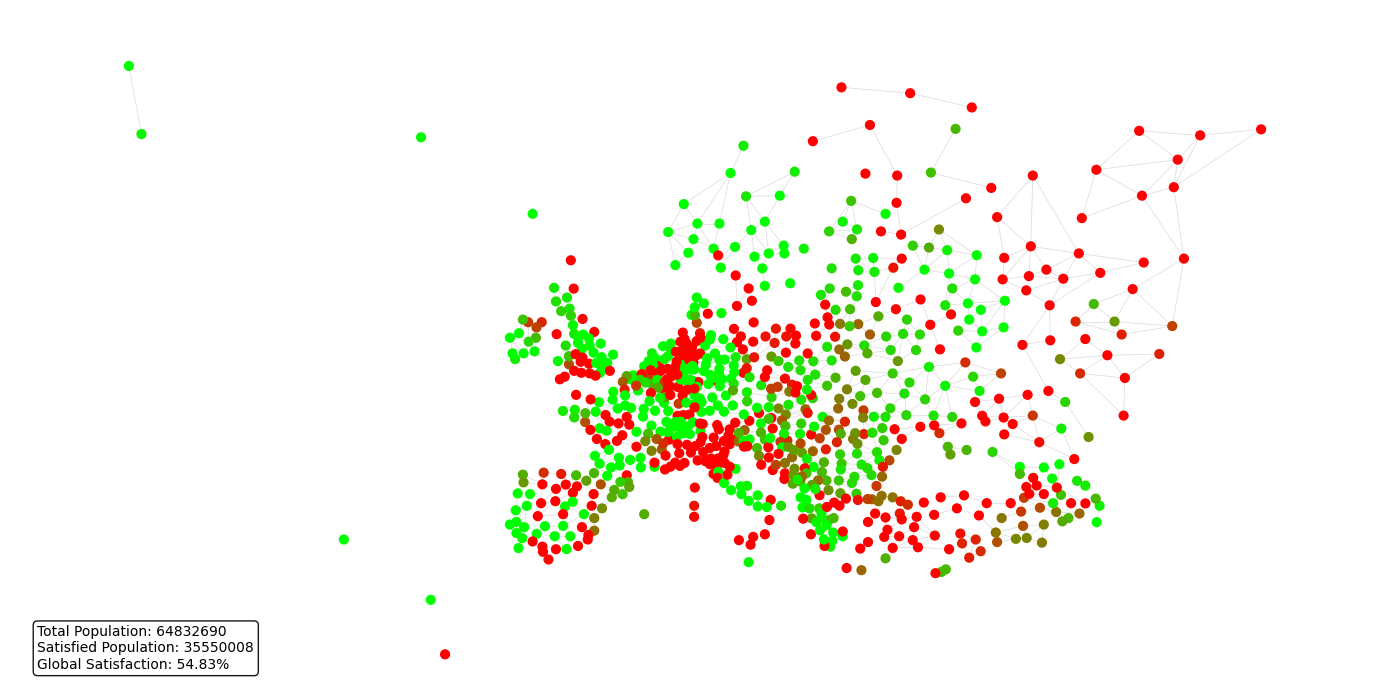

In [12]:
# 3.1. ALGORITMO MULTISTART (1000 Iteraciones)
print("Cargando resultados: Algoritmo Multistart...")

# Cargar la partición precalculada
partition_multistart = Partition.create_from_csv("multistartPartition.csv")
partitioned_multistart = LoadPartitionedGraph(base_graph, partition_multistart)

# Renderizar salidas en el Notebook
ShowPartitionedGraph(partitioned_multistart, show_labels=True)
ShowSatisfactionMap(partitioned_multistart)

Cargando resultados: Algoritmo DFS Ordenado por Prioridad...


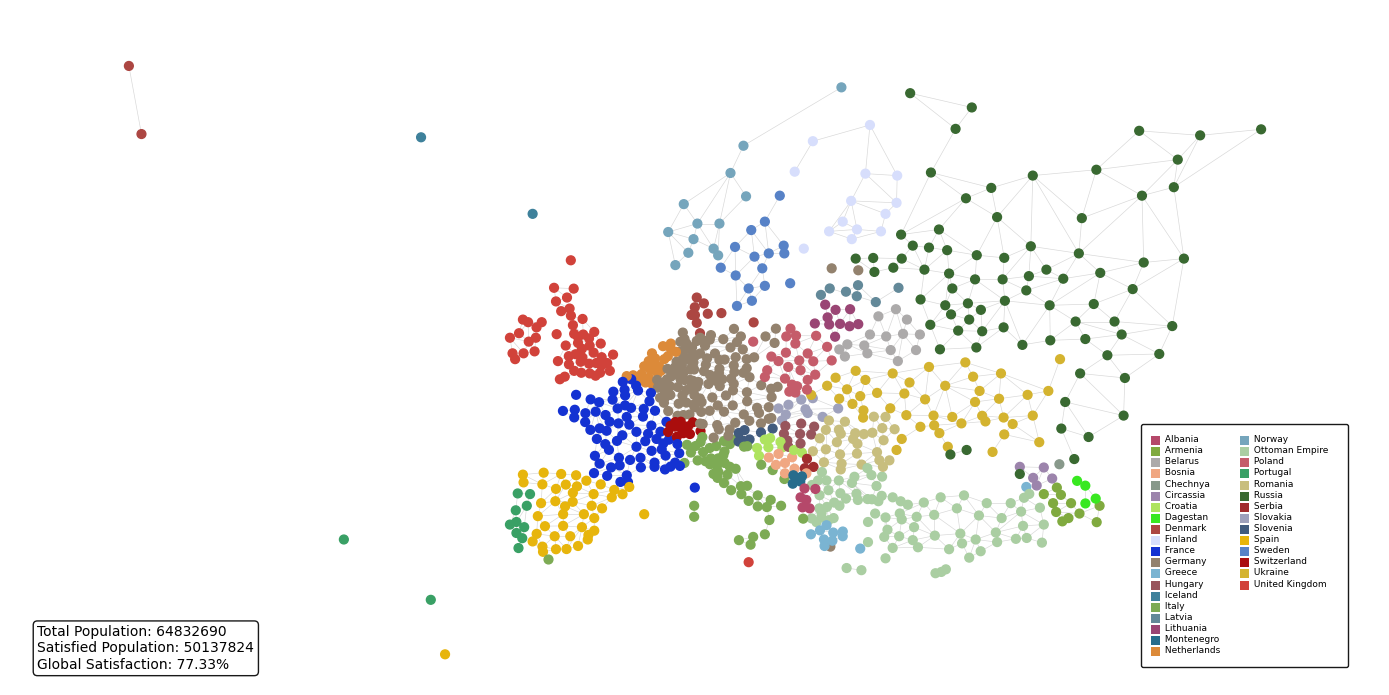

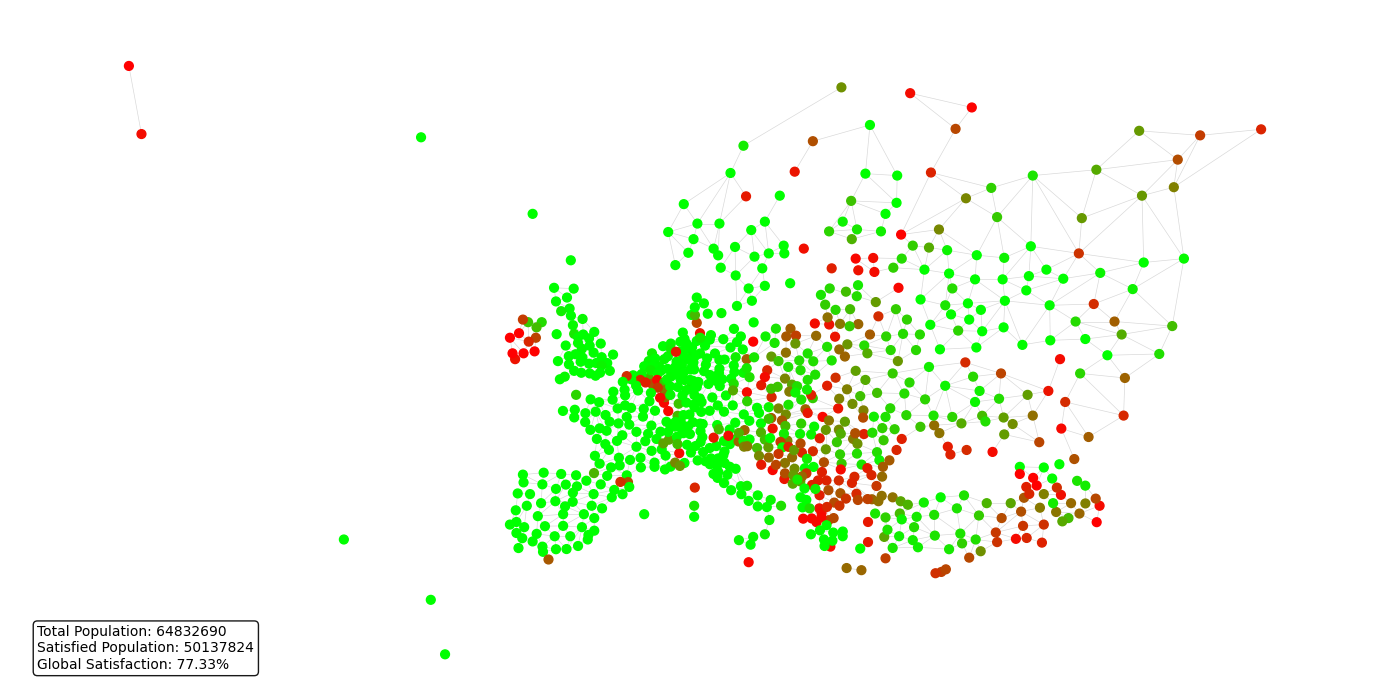

In [13]:
# 3.2. ALGORITMO DEPTH-FIRST SEARCH (DFS) ORDENADO
print("Cargando resultados: Algoritmo DFS Ordenado por Prioridad...")

# Cargar la partición precalculada
partition_dfs = Partition.create_from_csv("DFSPartitionOrdered.csv")
partitioned_dfs = LoadPartitionedGraph(base_graph, partition_dfs)

# Renderizar mapas
ShowPartitionedGraph(partitioned_dfs, show_labels=True)
ShowSatisfactionMap(partitioned_dfs)

Cargando resultados: Algoritmo BFS Ordenado con Protección de Capitales...


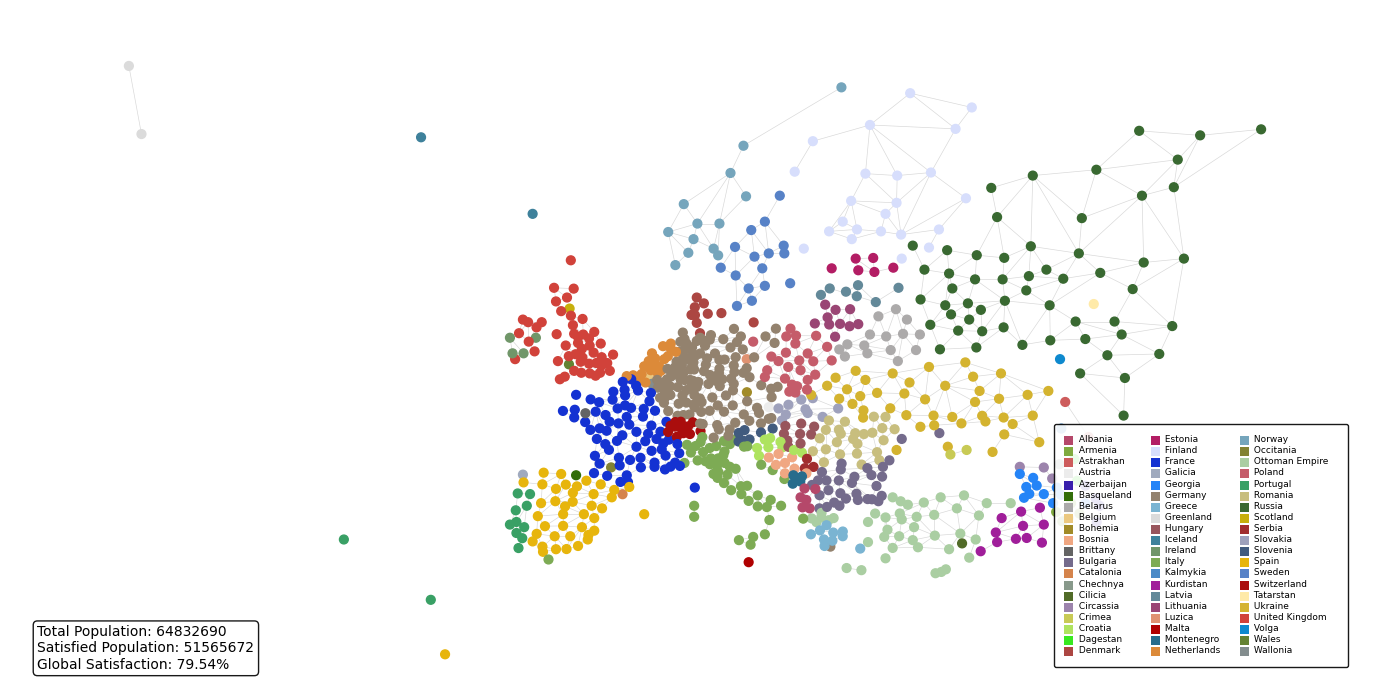

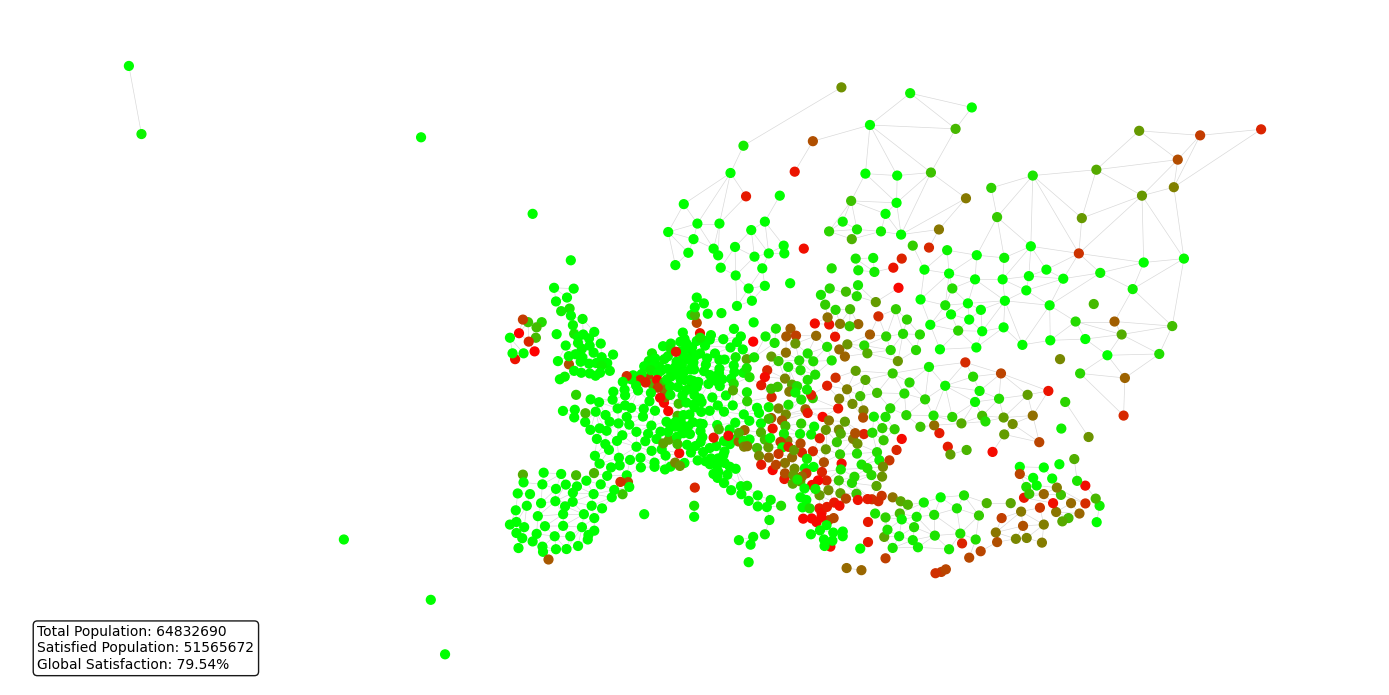

In [14]:
# 3.3. ALGORITMO BREADTH-FIRST SEARCH (BFS) ORDENADO
print("Cargando resultados: Algoritmo BFS Ordenado con Protección de Capitales...")

# Cargar la partición precalculada
partition_bfs = Partition.create_from_csv("BFSPartitionOrdered.csv")
partitioned_bfs = LoadPartitionedGraph(base_graph, partition_bfs)

# Renderizar mapas
ShowPartitionedGraph(partitioned_bfs, show_labels=True)
ShowSatisfactionMap(partitioned_bfs)

Cargando resultados: Greedy Frontier Expansion...


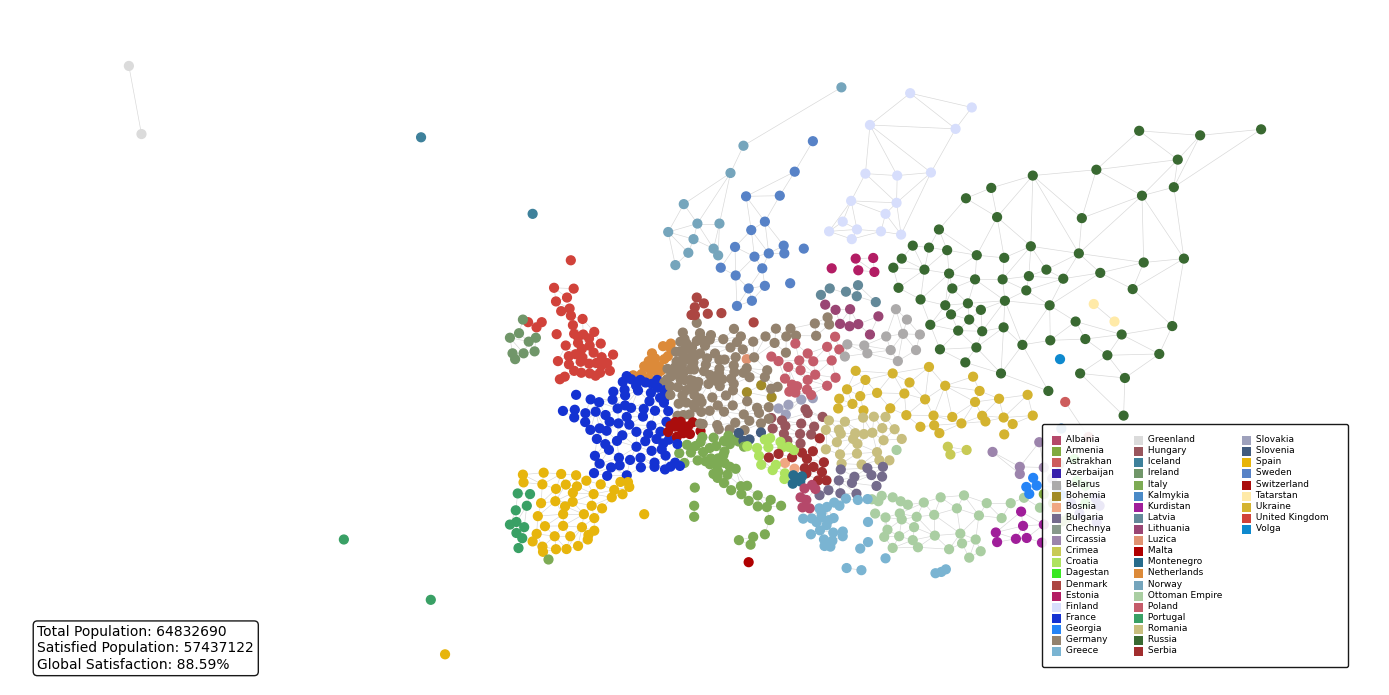

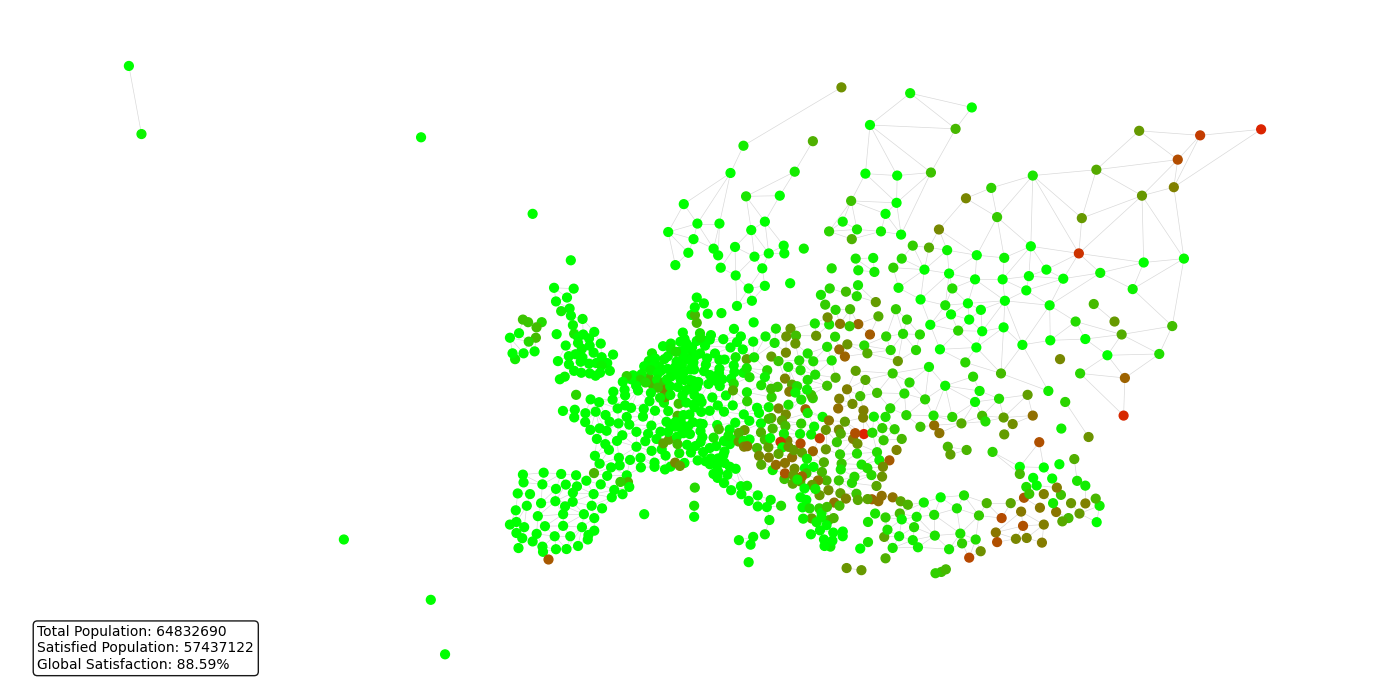

In [15]:
# 3.4. ALGORITMO GREEDY FRONTIER EXPANSION
print("Cargando resultados: Greedy Frontier Expansion...")

# Cargar la partición precalculada
partition_greedy = Partition.create_from_csv("greedyExpansionPartition.csv")
partitioned_greedy = LoadPartitionedGraph(base_graph, partition_greedy)

# Renderizar mapas
ShowPartitionedGraph(partitioned_greedy, show_labels=True)
ShowSatisfactionMap(partitioned_greedy)

Cargando resultados: Global Core Region (Solución Óptima Encontrada)...


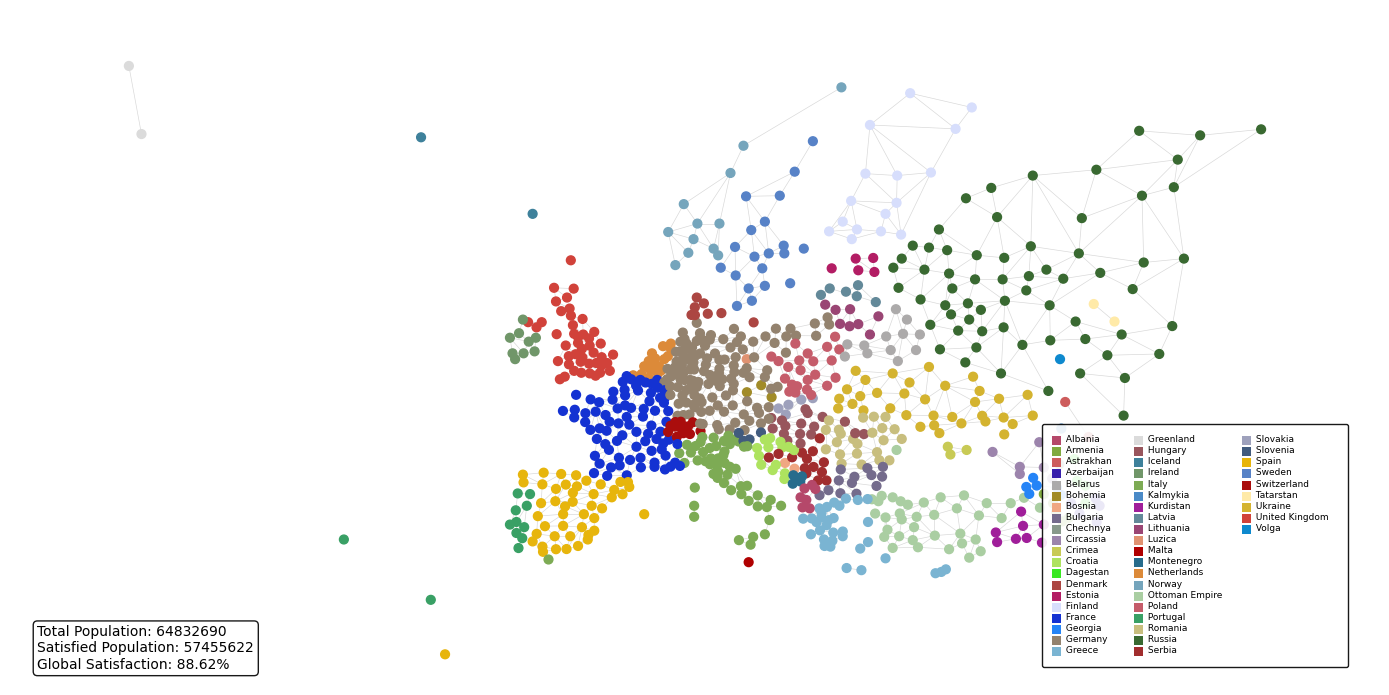

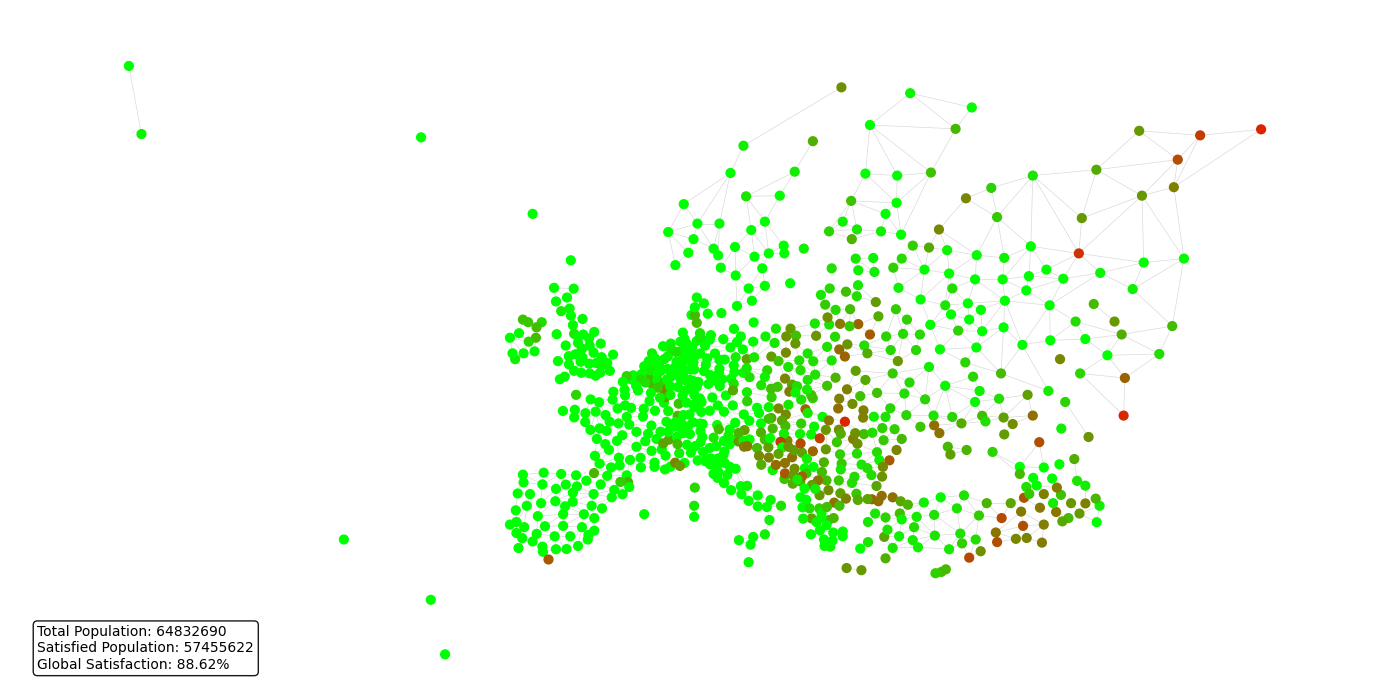

In [16]:
# 3.5. ALGORITMO GLOBAL CORE REGION WITH EXCLAVE RECOVERY
print("Cargando resultados: Global Core Region (Solución Óptima Encontrada)...")

# Cargar la partición precalculada
partition_global = Partition.create_from_csv("globalCoreRegionPartition.csv")
partitioned_global = LoadPartitionedGraph(base_graph, partition_global)

# Renderizar mapas
ShowPartitionedGraph(partitioned_global, show_labels=True)
ShowSatisfactionMap(partitioned_global)